<div style="text-align: center;">

# Assignment 3: Polytropic Ideal Chemical Reactors

Peter Schönung — Matriculation No. 1144689  
Chaudhry Ahmed — Matriculation No. 3060939  
Akshay Archak — Matriculation No. 3069479

</div>

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Mathematical Framework and Adaptations](#2-mathematical-framework-and-adaptations)
3. [Implementation and Verification](#3-implementation-and-verification)
3.1[Base Case](#31-base-case)
4. [Parameter Variation and Discussion](#4-parameter-variation-and-discussion)
5. [Conclusions](#5-conclusions)
6. [AI Use and Reflection](#6-ai-use-and-reflection)

---

## 1. Introduction

Tubular reactors are widely used in industry due to their straightforward construction, flexible design options, and suitability for continuous operation. Because the throughput of a tubular reactor in continuous use is large and efficient, most chemicals produced on an industrial scale are manufactured in tubular reactors. [1] This is also the case for the production of ethylene glycol (EG): in 2022, global production reached 56.97 megatonnes. [2] To meet this demand, industry relies on tubular reactors to produce ethylene glycol continuously.

In this assignment, we seek to simulate the hydrolysis of ethylene oxide (EO) to ethylene glycol (EG)

\begin{equation}
    \mathrm{EO} + \mathrm{H_2O} \rightarrow \mathrm{EG}
    \tag{1}
\end{equation}

inside a plug flow tubular reactor (PFTR). A PFTR is an idealised model of a tubular reactor in which plug flow is assumed: radial mixing is considered perfect, while axial backmixing is neglected entirely.

To simulate the reaction, a numerical ODE solver is used to compute the evolution of concentration and temperature along the reactor axis. Our goal is to simulate the resulting conversion for varying process and design parameters and to derive conclusions for an optimised reactor design from our findings. Given the aforementioned scale of ethylene glycol production, even incremental optimisation of the reactor harbours significant potential for reducing energy consumption, material input, and operating costs. The scope of this assignment is confined to idealised, one-dimensional modelling; results therefore cannot be transferred directly to real applications. Nevertheless, we seek to establish a conceptual framework for the hydrolysis of ethylene oxide on which further, more detailed work can reasonably be based.

In [1]:
# Importing the necessary libraries, put on top of the code for easy access and readability.
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ  # solve_ivp -> initial value problem

## 2. Mathematical framework and adaptations

For the simulation of the EO hydrolysis, we need a sound mathematical basis to describe the processes inside the PFTR. Starting with the reaction kinetics:

\begin{equation}
    r = k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}}
    \tag{2}
\end{equation}

\begin{equation}
    \frac{d c_{\mathrm{EO}}}{d t} = - r 
    \tag{3}
\end{equation}

\begin{equation}
    \frac{d c_{\mathrm{EG}}}{d t} = r 
    \tag{4}
\end{equation}

where:
- $r$ — reaction rate (mol L⁻¹ s⁻¹)
- $k_0$ — pre-exponential factor / frequency factor (s⁻¹)
- $E_A$ — activation energy (J mol⁻¹)
- $R$ — universal gas constant (J mol⁻¹ K⁻¹)
- $T$ — temperature (K)
- $c_{\mathrm{EO}}$ — molar concentration of ethylene oxide (mol L⁻¹)
- $c_{\mathrm{EG}}$ — molar concentration of ethylene glycol (mol L⁻¹)

Water is assumed to be present in excess, so its concentration is taken as constant. Equations 3 and 4 are formulated for a stirred tank reactor. For a PFTR, the time variable must be redefined. In a PFTR, the fluid travels as a plug throughout the reactor with no backmixing and no concentration gradients in the radial direction. Consequently, the residence time of a fluid element is proportional to the distance it has travelled along the reactor axis:

\begin{equation}
    t = \frac{x}{u}
    \tag{5}
\end{equation}

where:
- $t$ — residence time at position $x$ (s)
- $x$ — axial position along the reactor (m)
- $u$ — mean fluid velocity (m s⁻¹)

Assuming constant fluid velocity, equations 3 and 4 can be transformed to:

\begin{equation}
    u \cdot \frac{d c_{\mathrm{EO}}}{d x} = - r 
    \tag{6}
\end{equation}

\begin{equation}
    u \cdot \frac{d c_{\mathrm{EG}}}{d x} = r 
    \tag{7}
\end{equation}

The hydrolysis of EO (eq. 1) is highly exothermic ($\Delta_\mathrm{R}H = -92.2\,\mathrm{kJ\,mol^{-1}}$), meaning heat is released during the reaction, which may cause the reaction mixture to heat up. The energy balance inside the PFTR is described by: (taken from [1])

\begin{equation}
    \frac{4}{\pi} \frac{\dot{n} c_p}{d_R^2} \frac{dT}{dz} = \rho \, c_p \, u \frac{dT}{dz} = -\sum_j r_j \, \Delta_R H_j - h_W \frac{4}{d_R} \left( T - T_{Wall} \right) 
    \tag{8}
\end{equation}

Substituting the reaction rate from equation 2 for the single reaction considered here:

\begin{equation}
    \rho \, c_p \, u \frac{dT}{dz} = - k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_{\mathrm{EO}} \, \Delta_R H_j - h_W \frac{4}{d_R} \left( T - T_{Wall} \right)
    \tag{9}
\end{equation}

where:
- $\dot{n}$ — molar flow rate (mol s⁻¹)
- $\Delta_R H_j$ — reaction enthalpy of reaction $j$ (J mol⁻¹)
- $h_W$ — wall heat transfer coefficient (W m⁻² K⁻¹)
- $T_{Wall}$ — wall (jacket) temperature (K)
- $z$ — axial position along the reactor (m)

The heat released by the reaction will cause the mixture temperature to rise, while heat transfer through the reactor wall counteracts this increase. This is significant because the rate constant is a function of temperature, $k = k(T)$. With increasing temperature, the denominator of the exponent $E_A / RT$ grows, bringing the exponent $-E_A / RT$ closer to zero from below. Since the exponent is negative, this increases the value of the exponential term and, in turn, the value of $k(T)$. 

Our working hypothesis is therefore that the hydrolysis of EO proceeds faster at higher temperatures. Consequently, the reaction should be most efficient in an adiabatic reactor, where all released heat is retained to raise the temperature of the reaction mixture.

## 3. Implementation and verification

## 3.1 Base Case

To solve the equations we defined above, we choose a numerical approach. The equations above can be defined as an initial value problem, linking the concentration change of EO and EG and the Temperature change inside of the Reactor with the concentration of EO. 

The following values were given with the asignment as a starting point:
| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1\,\mathrm{m\,s^{-1}}$ |
| EO inlet concentration | $c_{\mathrm{EO},in}$ | $2.27\,\mathrm{mol\,L^{-1}}$ |
| Inlet temperature | $T_{in}$ | $423\,\mathrm{K}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2\,\mathrm{kJ\,mol^{-1}}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$ |
| Tube diameter | $d_\mathrm{R}$ | $0.03\,\mathrm{m}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5\,\mathrm{kJ\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Wall temperatures | $T_\mathrm{wall}$ | $423\,\mathrm{K}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |

Therefore we will do the first simulation run with these. 

In [2]:
# ============================================================
# Section 3 — Parameters (default case)
# ============================================================
# All quantities are converted to a CONSISTENT SI basis
# (m, s, mol, kg, K, J). The assignment table mixes unit systems;
# the two non-trivial conversions are flagged explicitly below.

# --- Physical constant ---
R = 8.314                 # universal gas constant             [J mol^-1 K^-1]

# --- Reaction kinetics (pre-exponential factor corrected to 5.01e6) ---
k0 = 5.01e6               # pre-exponential factor             [s^-1]
E_A = 72500.0             # activation energy                  [J mol^-1]
dH_R = -92.2e3            # reaction enthalpy (kJ -> J)         [J mol^-1]

# --- Process parameters ---
u = 1.0                   # mean fluid velocity                [m s^-1]
c_EO_in = 2.27 * 1e3      # inlet EO conc. (mol/L -> mol/m^3)   [mol m^-3]  <-- unit conversion
T_in = 423.0              # inlet temperature                  [K]

# --- Fluid properties ---
rho = 1000.0              # mixture density                    [kg m^-3]
c_p = 4.19e3              # specific heat capacity (kJ -> J)    [J kg^-1 K^-1]

# --- Reactor geometry & wall ---
d_R = 0.03                # tube diameter                      [m]
h_W = 0.5e3               # wall heat-transfer coeff (kJ -> W)  [W m^-2 K^-1]  <-- unit conversion
T_wall = 423.0            # wall (jacket) temperature          [K]
L = 300.0                 # reactor length                     [m]

In [3]:
# ============================================================
# Section 3 — Model: reaction kinetics and PFTR balances
# ============================================================

def kinetics(T, c_EO):
    """Reaction rate of the EO hydrolysis (1st order in EO, Arrhenius).

    r = k0 * exp(-E_A / (R*T)) * c_EO        [mol m^-3 s^-1]
    Water is in large excess, so its concentration is constant
    and absorbed into the pseudo-first-order rate constant.
    """
    k = k0 * np.exp(-E_A / (R * T))          # rate constant      [s^-1]
    r = k * c_EO                             # reaction rate      [mol m^-3 s^-1]
    return r


def PFTR(z, f):
    """RHS of the steady-state PFTR ODE system in the axial coordinate z.

    State vector f = [c_EO, c_EG, T].
    Material balance (Guettel Eq. 11.2a, p. 142):  u * dc_i/dz = nu_i * r
    Energy balance   (Guettel Eq. 11.2b, p. 142):  rho * c_p * u * dT/dz = -r * dH_R - h_W * (4/d_R) * (T - T_wall)
    """
    c_EO, c_EG, T = f                        # unpack state vector

    r = kinetics(T, c_EO)                    # reaction rate      [mol m^-3 s^-1]

    dc_EO_dz = -r / u                        # EO consumed        [mol m^-4]
    dc_EG_dz = +r / u                        # EG formed          [mol m^-4]
    dT_dz = (-r * dH_R - h_W * (4.0 / d_R) * (T - T_wall)) / (rho * c_p * u)  # [K m^-1]

    return [dc_EO_dz, dc_EG_dz, dT_dz]

In [4]:
# ============================================================
# Section 3 — Numerical solution of the default case
# ============================================================
# Initial value problem: integrate the PFTR system over z in [0, L].
# The Arrhenius coupling can make the system stiff, so LSODA is used
# (automatic stiff/non-stiff switching). Tight tolerances are set for
# a reproducible, solver-independent solution.

# Initial conditions at the reactor inlet (z = 0)
f_init = [c_EO_in, 0.0, T_in]                # [c_EO, c_EG, T]

# Axial integration span and output grid
z_span = (0.0, L)                            # integration interval  [m]
z_eval = np.linspace(0.0, L, 3001)           # output positions      [m]

# Solve the initial value problem
sol = integ.solve_ivp(
    PFTR, z_span, f_init,
    method="LSODA",
    t_eval=z_eval,
    rtol=1e-8, atol=1e-8,
)

# Unpack solution profiles for convenience
z_grid = sol.t                               # axial position    [m]
c_EO = sol.y[0]                              # EO concentration  [mol m^-3]
c_EG = sol.y[1]                              # EG concentration  [mol m^-3]
T = sol.y[2]                                 # temperature       [K]
X_EO = 1.0 - c_EO / c_EO_in                  # EO conversion     [-]

# --- quick sanity output (optional, can be removed in the final report) ---
print(f"Solver success      : {sol.success}")
print(f"Conversion at outlet: X_EO = {X_EO[-1]:.4f}")
print(f"Outlet temperature  : T    = {T[-1]:.2f} K")
print(f"Hot spot            : T_max = {T.max():.2f} K at z = {z_grid[np.argmax(T)]:.1f} m")
print(f"Mass-balance check  : max|c_EO + c_EG - c_EO_in| = {np.max(np.abs(c_EO + c_EG - c_EO_in)):.2e} mol/m^3")

Solver success      : True
Conversion at outlet: X_EO = 0.9262
Outlet temperature  : T    = 426.44 K
Hot spot            : T_max = 437.31 K at z = 98.1 m
Mass-balance check  : max|c_EO + c_EG - c_EO_in| = 1.82e-12 mol/m^3


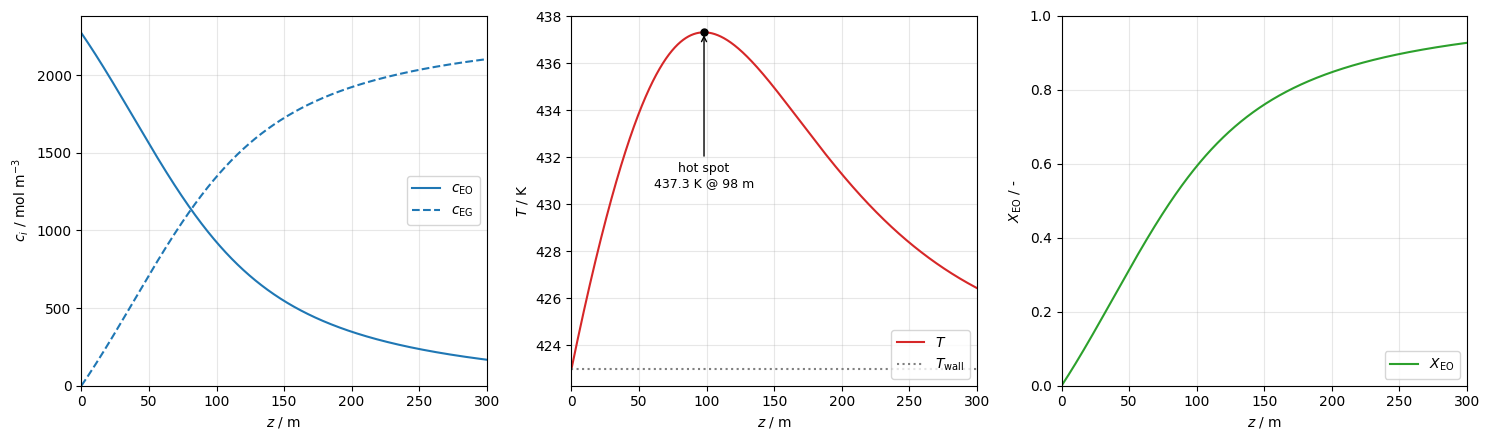

In [5]:
# ============================================================
# Section 3 — Visualization of the default case
# ============================================================
# Three panels along the reactor axis z:
#   (1) species concentrations, (2) temperature with hot spot,
#   (3) EO conversion. Axes are labelled as "symbol / unit".

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# --- (1) Concentration profiles ---
ax1.plot(z_grid, c_EO, color="tab:blue", label=r"$c_\mathrm{EO}$")
ax1.plot(z_grid, c_EG, color="tab:blue", ls="--", label=r"$c_\mathrm{EG}$")
ax1.set(xlabel=r"$z$ / m", ylabel=r"$c_i$ / mol m$^{-3}$")
ax1.set_xlim(0, L); ax1.set_ylim(bottom=0)
ax1.legend(); ax1.grid(alpha=0.3)

# --- (2) Temperature profile with hot spot ---
i_hot = np.argmax(T)
ax2.plot(z_grid, T, color="tab:red", label=r"$T$")
ax2.axhline(T_wall, color="gray", ls=":", label=r"$T_\mathrm{wall}$")
ax2.plot(z_grid[i_hot], T[i_hot], "o", color="black", ms=5)
ax2.annotate(f"hot spot\n{T[i_hot]:.1f} K @ {z_grid[i_hot]:.0f} m",
                 xy=(z_grid[i_hot], T[i_hot]),          # arrow tip = hot spot
                 xytext=(z_grid[i_hot], T[i_hot] - 5.5),  # text directly below, same z
                 ha="center", va="top",                 # centred under the point
                 arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)
ax2.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K")
ax2.set_xlim(0, L); ax2.legend(loc="lower right"); ax2.grid(alpha=0.3)

# --- (3) Conversion profile ---
ax3.plot(z_grid, X_EO, color="tab:green", label=r"$X_\mathrm{EO}$")
ax3.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -")
ax3.set_xlim(0, L); ax3.set_ylim(0, 1)
ax3.legend(loc="lower right"); ax3.grid(alpha=0.3)

fig.tight_layout()

## 3.2 Verification of the model

To verify the model we created, we perform four different checks:

---

> **Verification 1:**

We use the isothermal case to check the numerical solver against a clean analytical solution. The temperature is held at the inlet value $T_{in}$, so the rate constant $k(T_{in})$ stays constant along the whole length of the reactor and the energy balance is inactive. The EO balance then reduces to

\begin{equation}
    u \, \frac{dc_{EO}}{dz} = -k(T_{in}) \, c_{EO}
    \tag{10}
\end{equation}

which has the clean analytical solution

\begin{equation}
    c_{EO}(z) = c_{EO,in} \, \exp\!\left(-\frac{k(T_{in})}{u} \, z\right)
    \tag{11}
\end{equation}

By simulating the reactor with the numerical solver for the isothermal case and comparing the result with the analytical solution, we obtain the maximum deviation between the two profiles over the length of the PFTR. Relative deviations smaller than 1e-5 are considered within the solver tolerance level.

---

> **Verification 2:**

We check the material balance for the correct conversion of EO to EG. The stoichiometric conversion is 1:1, so the sum of outgoing EO and EG must equal the incoming amount of EO. Because the density of the mixture is assumed constant, we can check the material balance directly via the concentrations of the incoming and outgoing streams. Values below 1e-6 are considered permissible for solver deviation.

---

> **Verification 3:**

We check the other edge case besides isothermal behaviour: an adiabatic PFTR. In this case, the heat transfer to the wall is set to 0, which simplifies the energy balance to:

\begin{equation}
    \rho \, c_p \, u \frac{dT}{dz} = - k_{0} \exp\!\left(-\frac{E_{A}}{R\, T}\right) c_{\mathrm{EO}} \, \Delta_R H_j
    \tag{12}
\end{equation}

In the adiabatic case we also obtain an analytical solution. The temperature rise can be described as

\begin{equation}
    T(z) = T_{in} + \Delta T_{ad} \, X_{EO}(z),
    \tag{13}
\end{equation}

with $\Delta T_{ad}$ being the adiabatic temperature increase, defined through the Prater number $\beta$ (a dimensionless number)

\begin{equation}
    \beta_j \equiv \frac{\Delta T_{\mathrm{ad}}}{T_i} = \frac{\Delta_R H \, c_{EO,i}}{\nu_{EO} \, \rho \, c_p \, T_i}
    \tag{14}
\end{equation}

and $X_{EO}(z)$ being the conversion of EO at the current point inside the reactor as a fraction (0 to 1). At 100% conversion the total possible temperature rise through heat released by the reaction equals the aforementioned adiabatic temperature increase. Comparing the analytical solution at all evaluated points inside the reactor gives the maximum deviation between the expected and calculated value. Deviations smaller than 1e-3 are considered permissible for solver deviation.

---

> **Verification 4:**

To confirm that the result is independent of the solver settings, we vary the tolerance values rtol/atol stepwise from 1e-4 to 1e-10 and verify that the key outputs stop changing. In addition, we repeat the integration with a different method than "LSODA", to rule out that the result is an artifact of one particular integration scheme. If all methods yield the same result, the solution can be considered solver-independent.

In [6]:
# ============================================================
# Verification 1 — Isothermal analytical limit
# ============================================================
# Rationale (CRE):
#   If all heat effects are switched off, the temperature stays at T_in and the EO balance reduces to a linear, first-order ODE in the axial coordinate: 
#   u * dc_EO/dz = -k(T_in) * c_EO
#   This has the well-known closed-form solution of a first-order reaction in an ideal PFTR (analogous to a first-order batch reactor): 
#   c_EO(z) = c_EO_in * exp(-k(T_in)/u * z)
#   Comparing the numerical solver against this EXACT result validates the whole numerical pipeline (RHS assembly, kinetics, integration, division by u).

k_in = k0 * np.exp(-E_A / (R * T_in))                       # rate constant at inlet temperature [s^-1]

# (a) Numerical solution of the isothermal material balance (scalar ODE, T = T_in)
def rhs_isothermal(z, c):
    # u dc_EO/dz = -k(T_in) c_EO   -> temperature pinned, energy balance inactive
    return [-kinetics(T_in, c[0]) / u]

sol_iso = integ.solve_ivp(rhs_isothermal, (0.0, L), [c_EO_in], method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8)
c_EO_num = sol_iso.y[0]                                     # numerical profile [mol m^-3]

# (b) Exact analytical solution on the same axial grid
c_EO_ana = c_EO_in * np.exp(-k_in / u * z_eval)  # closed-form profile [mol m^-3]

# (c) Compare numerical vs. analytical
abs_err = np.max(np.abs(c_EO_num - c_EO_ana))               # absolute deviation [mol m^-3]
rel_err = np.max(np.abs(c_EO_num - c_EO_ana) / c_EO_in)     # relative deviation [-]

print("Verification 1 - isothermal analytical limit")
print(f"  isothermal outlet conversion : X = {1 - c_EO_num[-1]/c_EO_in:.4f}")
print(f"  max |numerical - analytical| : {abs_err:.2e} mol/m^3")
print(f"  max relative deviation       : {rel_err:.2e}")
print(f"  -> {'PASS' if rel_err < 1e-5 else 'CHECK'} (deviation at solver-tolerance level)\n")

Verification 1 - isothermal analytical limit
  isothermal outlet conversion : X = 0.8126
  max |numerical - analytical| : 4.31e-05 mol/m^3
  max relative deviation       : 1.90e-08
  -> PASS (deviation at solver-tolerance level)



In [7]:
# ============================================================
# Verification 2 — Atom / mass balance
# ============================================================
# Rationale (CRE):
#   The stoichiometry is 1 EO -> 1 EG and the density is constant, so no carbon can be lost: every EO molecule consumed must appear as an EG molecule. Hence the sum of both concentrations equals the feed value at EVERY position:
#       c_EO(z) + c_EG(z) = c_EO_in
#   IMPORTANT: this is a NECESSARY but NOT SUFFICIENT check. It would also be satisfied if both reaction rates were scaled by the same wrong factor. It is therefore used together with the analytical checks 1 and 3.

mass_residual = np.max(np.abs(c_EO + c_EG - c_EO_in))    # on the default solution [mol m^-3]

print("Verification 2 - atom/mass balance (default case)")
print(f"  max |c_EO + c_EG - c_EO_in| : {mass_residual:.2e} mol/m^3")
print(f"  -> {'PASS' if mass_residual < 1e-6 else 'CHECK'} (conserved to machine precision)\n")

Verification 2 - atom/mass balance (default case)
  max |c_EO + c_EG - c_EO_in| : 1.82e-12 mol/m^3
  -> PASS (conserved to machine precision)



In [8]:
# ============================================================
# Verification 3 — Adiabatic limit (energy balance)
# ============================================================
# Rationale (CRE):
#   With no wall heat transfer (h_W = 0) the reactor is adiabatic: all reaction heat is stored as sensible heat of the fluid. Combining the material and energy balance then yields an EXACT first integral, independent of kinetics:
#       T(z) = T_in + dT_ad * X_EO(z)
#   with the ADIABATIC TEMPERATURE RISE
#       dT_ad = -dH_R * c_EO_in / (rho * c_p)
#   (equivalent to the dimensionless PRATER number beta via dT_ad = beta * T_in; Guettel & Turek, Chem. Reaktionstechnik, Eq. 11.6b, p. 143).
#   This validates the heat-release term and the rho*c_p*u factor of the energy balance - precisely the part that check 1 (with dH_R = 0) does not test.

dT_ad = -dH_R * c_EO_in / (rho * c_p)            # adiabatic temperature rise [K]

# Adiabatic solve: full PFTR system but with h_W = 0 (wall term switched off)
def rhs_adiabatic(z, f):
    c_EO, c_EG, T = f
    r = kinetics(T, c_EO)
    dc_EO_dz = -r / u
    dc_EG_dz = +r / u
    dT_dz = (-r * dH_R) / (rho * c_p * u)        # h_W = 0 -> no wall heat removal
    return [dc_EO_dz, dc_EG_dz, dT_dz]

sol_ad = integ.solve_ivp(rhs_adiabatic, (0.0, L), [c_EO_in, 0.0, T_in], method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8)
c_EO_ad, T_ad = sol_ad.y[0], sol_ad.y[2]
X_ad = 1.0 - c_EO_ad / c_EO_in

# (a) Outlet temperature vs. expectation at the achieved conversion
T_expected_out = T_in + dT_ad * X_ad[-1]
# (b) Stronger: the linear T-X relation must hold along the WHOLE reactor
T_linear = T_in + dT_ad * X_ad
max_dev = np.max(np.abs(T_ad - T_linear))        # [K]

print("Verification 3 - adiabatic limit")
print(f"  adiabatic temperature rise dT_ad : {dT_ad:.2f} K")
print(f"  adiabatic outlet conversion      : X = {X_ad[-1]:.4f}")
print(f"  outlet temperature T_out         : {T_ad[-1]:.2f} K (expected {T_expected_out:.2f} K)")
print(f"  max |T - (T_in + dT_ad*X)|       : {max_dev:.2e} K")
print(f"  -> {'PASS' if max_dev < 1e-3 else 'CHECK'} (T-X coupling exact along the reactor)\n")

Verification 3 - adiabatic limit
  adiabatic temperature rise dT_ad : 49.95 K
  adiabatic outlet conversion      : X = 1.0000
  outlet temperature T_out         : 472.95 K (expected 472.95 K)
  max |T - (T_in + dT_ad*X)|       : 7.39e-13 K
  -> PASS (T-X coupling exact along the reactor)



In [9]:
# ============================================================
# Verification 4 — Numerical convergence & solver independence
# ============================================================
# Rationale (CRE / numerics):
#   A trustworthy result must be a property of the MODEL, not of the solver settings. We therefore (a) tighten the integration tolerances step by step and confirm that the key outputs stop changing, and (b) repeat the solve with different integration methods and confirm they agree.
#   NOTE: t_eval only sets the OUTPUT sampling (dense-output interpolation); the actual accuracy is controlled by rtol/atol, not by the output grid.

def solve_default(method, rtol, atol):
    """Solve the default polytropic case; return (X_out, T_max, T_out).
    Uses dense output evaluated on a fixed fine grid so that the hot-spot
    temperature T_max is captured consistently across all solvers."""
    s = integ.solve_ivp(PFTR, (0.0, L), [c_EO_in, 0.0, T_in],
                        method=method, rtol=rtol, atol=atol, dense_output=True)
    zz = np.linspace(0.0, L, 3001)
    cc, _, TT = s.sol(zz)
    return 1.0 - cc[-1] / c_EO_in, TT.max(), TT[-1]

print("Verification 4 - convergence & solver independence")

# (a) Tolerance study with a single solver
print("  tolerance study (LSODA):")
print(f"    {'rtol=atol':>10} | {'X_out':>8} | {'T_max/K':>9} | {'T_out/K':>9}")
for tol in [1e-4, 1e-6, 1e-8, 1e-10]:
    X_out, T_max, T_out = solve_default("LSODA", tol, tol)
    print(f"    {tol:>10.0e} | {X_out:8.5f} | {T_max:9.4f} | {T_out:9.4f}")

# (b) Cross-check with different solvers at tight tolerance
print("  solver comparison at rtol = atol = 1e-10:")
for m in ["LSODA", "BDF", "Radau"]:
    X_out, T_max, T_out = solve_default(m, 1e-10, 1e-10)
    print(f"    {m:>6}: X_out = {X_out:.6f}, T_max = {T_max:.4f} K, T_out = {T_out:.4f} K")

Verification 4 - convergence & solver independence
  tolerance study (LSODA):
     rtol=atol |    X_out |   T_max/K |   T_out/K


         1e-04 |  0.92626 |  437.3162 |  426.4415
         1e-06 |  0.92621 |  437.3120 |  426.4401
         1e-08 |  0.92621 |  437.3120 |  426.4402
         1e-10 |  0.92621 |  437.3120 |  426.4402
  solver comparison at rtol = atol = 1e-10:
     LSODA: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K
       BDF: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K
     Radau: X_out = 0.926207, T_max = 437.3120 K, T_out = 426.4402 K


## 4. Parameter variation and discussion

In [24]:
# ============================================================
# Section 4 — Parameter variation: wall heat transfer
#             (adiabatic -> isothermal via h_wall)
# ============================================================
# >>> EDIT ONLY THIS ARRAY to add/remove/change cases. <
# Sentinel values:  0   -> adiabatic   (no wall heat removal)
#                   inf -> isothermal  (temperature pinned at T_in)
# Any positive finite value is a polytropic case with that h_wall.
# The plotting cell adapts automatically to ANY number of cases.
h_wall_values = [0.0, 125.0, 250.0, 500.0, 1000.0, 2000.0, np.inf]   # [W m^-2 K^-1]
# h_wall_values = [0.0, 125.0, 250.0, 350.0, 500.0, 750.0, 1000.0, 2000.0, 3000.0, np.inf]   # [W m^-2 K^-1]

# Shared axial output grid (same x-axis sampling for every case)
z_eval = np.linspace(0.0, L, 3001)

def solve_case(h_wall_value):
    """Solve the PFTR for a single wall heat-transfer coefficient.

    Returns the axial profiles (z, c_EO, c_EG, T, X_EO) sampled on z_eval.
    - h_wall_value = inf -> isothermal limit: the temperature is pinned at T_in
      and only the material balance is integrated (avoids stiffness / 'inf').
    - any finite value (including 0 = adiabatic) -> full 3-equation system.
    """
    if np.isinf(h_wall_value):
        # isothermal: u dc_EO/dz = -k(T_in) c_EO,  T = T_in = const.
        sol = integ.solve_ivp(lambda z, c: [-kinetics(T_in, c[0]) / u],
                              (0.0, L), [c_EO_in],
                              method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8)
        c_EO = sol.y[0]
        c_EG = c_EO_in - c_EO                 # from the 1:1 mass balance
        T = np.full_like(z_eval, T_in)        # temperature stays constant
    else:
        # polytropic / adiabatic: full system with the given h_wall
        def rhs(z, f):
            c_EO, c_EG, T = f
            r = kinetics(T, c_EO)
            dT_dz = (-r * dH_R - h_wall_value * (4.0 / d_R) * (T - T_wall)) / (rho * c_p * u)
            return [-r / u, +r / u, dT_dz]
        sol = integ.solve_ivp(rhs, (0.0, L), [c_EO_in, 0.0, T_in],
                             method="LSODA", t_eval=z_eval, rtol=1e-8, atol=1e-8)
        c_EO, c_EG, T = sol.y

    X_EO = 1.0 - c_EO / c_EO_in
    return z_eval, c_EO, c_EG, T, X_EO

# Solve every case in the array
results = [solve_case(h) for h in h_wall_values]

def case_label(h):
    """Legend label for a given h_wall value (handles the two limits)."""
    if h == 0:      return r"$h_\mathrm{wall}=0$ (adiabatic)"
    if np.isinf(h): return r"$h_\mathrm{wall}\to\infty$ (isothermal)"
    return rf"$h_\mathrm{{wall}}={h:.0f}$"

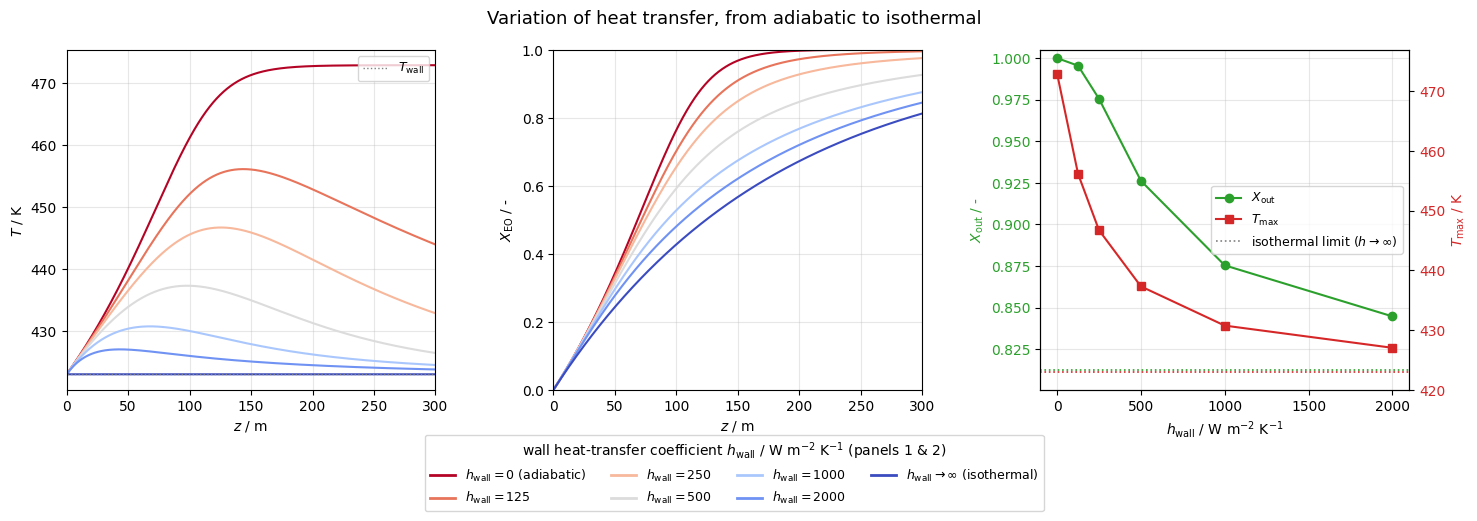

In [25]:
# ============================================================
# Section 4 — Heat-transfer variation: temperature & conversion
#             profiles plus the conversion/temperature trade-off
# ============================================================
n_cases = len(h_wall_values)

# Colour map keyed to the case INDEX -> adapts to any number of cases.
# Low cooling (adiabatic) = warm/red, strong cooling (isothermal) = cool/blue.
colors = [plt.cm.coolwarm(1.0 - i / max(n_cases - 1, 1)) for i in range(n_cases)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: temperature profiles T(z) ; Panel 2: conversion profiles X(z) ---
for (z, c_EO, c_EG, T, X), col in zip(results, colors):
    ax1.plot(z, T, color=col)
    ax2.plot(z, X, color=col)

ax1.axhline(T_wall, color="gray", ls=":", lw=1, label=r"$T_\mathrm{wall}$")   # reference
ax1.set(xlabel=r"$z$ / m", ylabel=r"$T$ / K");            ax1.set_xlim(0, L)
ax2.set(xlabel=r"$z$ / m", ylabel=r"$X_\mathrm{EO}$ / -"); ax2.set_xlim(0, L); ax2.set_ylim(0, 1)
ax1.legend(loc="upper right", fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)

# --- Panel 3: trade-off of outlet conversion and hot-spot temperature vs h_wall ---
# Split the cases into finite ones (plotted as points) and the isothermal limit
# (h -> inf, drawn as a horizontal asymptote). Fully driven by h_wall_values.
h_fin, X_out, T_max = [], [], []
X_iso = T_iso = None
for h, (z, c_EO, c_EG, T, X) in zip(h_wall_values, results):
    if np.isinf(h):
        X_iso, T_iso = X[-1], T.max()            # isothermal asymptotes
    else:
        h_fin.append(h); X_out.append(X[-1]); T_max.append(T.max())

# sort by h_wall so the connecting line is monotone even if the array is unordered
order = np.argsort(h_fin)
h_fin = np.array(h_fin)[order]; X_out = np.array(X_out)[order]; T_max = np.array(T_max)[order]

ax3b = ax3.twinx()                                # second y-axis (temperature)
l1, = ax3.plot(h_fin, X_out, "o-", color="tab:green", label=r"$X_\mathrm{out}$")
l2, = ax3b.plot(h_fin, T_max, "s-", color="tab:red", label=r"$T_\mathrm{max}$")
handles = [l1, l2]

if X_iso is not None:                             # draw isothermal limits if present
    ax3.axhline(X_iso, color="tab:green", ls=":", lw=1.2)
    ax3b.axhline(T_iso, color="tab:red", ls=":", lw=1.2)
    ax3.set_ylim(X_iso - 0.012, 1.005)
    ax3b.set_ylim(T_iso - 3, T_max.max() + 4)
    handles.append(Line2D([0], [0], color="gray", ls=":", lw=1.2,
                          label=r"isothermal limit ($h\to\infty$)"))

ax3.set_xlabel(r"$h_\mathrm{wall}$ / W m$^{-2}$ K$^{-1}$")
ax3.set_ylabel(r"$X_\mathrm{out}$ / -", color="tab:green")
ax3b.set_ylabel(r"$T_\mathrm{max}$ / K", color="tab:red")
ax3.tick_params(axis="y", labelcolor="tab:green")
ax3b.tick_params(axis="y", labelcolor="tab:red")
ax3.grid(alpha=0.3)
ax3.legend(handles=handles, loc="center right", fontsize=9)

# --- shared, adaptive case legend (panels 1 & 2) below the figure ---
from matplotlib.lines import Line2D
case_handles = [Line2D([0], [0], color=col, lw=2, label=case_label(h))
                for col, h in zip(colors, h_wall_values)]
fig.legend(handles=case_handles, loc="lower center", bbox_to_anchor=(0.5, -0.035),
           ncol=min(n_cases, 4), fontsize=9,
           title=r"wall heat-transfer coefficient $h_\mathrm{wall}$ / W m$^{-2}$ K$^{-1}$ (panels 1 & 2)")

fig.suptitle("Variation of heat transfer, from adiabatic to isothermal", fontsize=13)
fig.subplots_adjust(left=0.055, right=0.95, top=0.90, bottom=0.22, wspace=0.32)

# 5. Conclusions

## 6. AI Use and Reflection

### 6.1 Tools Used

| Tool | Model / Version | Date(s) of Use |
|------|-----------------|----------------|
| Claude | Sonnet 4.6 | [Month Year] |
| [Additional tool, if any] | [Version] | [Date] |

---

### 6.2 Areas of Use

| Subtask | AI Used? | Notes |
|--------|----------|-------|
| Literature / data research | [ ] Yes / [x] No | |
| Code generation | [x] Yes | PFTR ODE implementation |
| Code debugging | [x] Yes | [brief description] |
| Verification strategy | [ ] Yes / [ ] No | |
| Concept clarification (self-study) | [ ] Yes / [ ] No | |
| Interpretation of numerical results | [ ] Yes / [ ] No | |
| Language editing / proof-reading | [ ] Yes / [ ] No | |

---

### 6.3 Prompting Strategy

**Code generation (PFTR implementation):**  
[Describe briefly: What context did you provide? How did you structure the prompt?
Example: "We provided the material and energy balance equations, parameter table,
and the existing bSTR code structure, then asked for a PFTR adaptation using
space-time equivalence. Prompts were iterative — first requesting a skeleton,
then refining unit handling and sign conventions."]

**[Further area of use, if applicable]:**  
[Description]

> Verbatim chat protocols are provided as a separate PDF appendix.

---

### 6.4 Critical Examination

**Code verification:**  
[Describe your verification approach. Example: "The PFTR output was checked
against the isothermal limiting case (analytical solution), and the adiabatic
case (energy balance checked via enthalpy balance). Detected issue: [describe].
Correction: [describe]."]

**Kinetic / thermodynamic data:**  
All parameter values (k₀, Eₐ, ΔᵣH, ρ, cₚ) were taken directly from the
assignment specification and cross-checked against [source, e.g. Barrón et al.,
NIST, textbook]. No AI-generated numerical values were used without independent
verification.

**Literature references:**  
[If AI suggested references: "All literature references suggested by AI were
independently verified via [Google Scholar / DOI lookup / library portal].
[X] reference(s) could not be confirmed and were discarded."]

**Errors and hallucinations encountered:**  
[Example: "The initial code suggestion used incorrect sign convention for the
heat source term in the energy balance. This was detected by checking the
adiabatic temperature rise against the analytical estimate (ΔT = −ΔᵣH · Δc / ρcₚ)
and corrected manually."]

---

### 6.5 Statement of Own Contribution

[1–3 sentences. Example: "The selection of verification strategies, the
scientific interpretation of concentration and temperature profiles, the
engineering discussion of design parameters, and all conclusions drawn
are our own independent work. AI was used exclusively for code implementation
and debugging; the underlying modelling logic and result discussion were
developed independently by the authors."]

---

# 7. Literature

[1] R. Güttel und T. Turek, Chemische Reaktionstechnik, https://doi.org/10.1007/978-3-662-63150-8

[2] GlobalData. (May 4, 2023). Production capacity of ethylene glycol worldwide from 2014 to 2022 (in million metric tons) [Graph]. In Statista. Retrieved June 10, 2026, from https://www.statista.com/statistics/1067418/global-ethylene-glycol-production-capacity/

# 📋 Progress Tracker — Assignment 3

> **Last updated:** [10.06.2026] | **Status:** 🔴 Not started / 🟡 In progress / 🟢 Done

| # | Task | Status | Comments / Notes |
|---|------|--------|-----------------|
| 1 | **Mathematical framework** — describe space-time transformation (bSTR → PFTR), adapt material & energy balance equations | 🟡 | Ive done a first draft, maybe expand on that. |
| 2 | **Code implementation** — adapt bSTR ODE system to PFTR (spatial coordinate z, heat transfer geometry) | 🟢 | |
| 3 | **Literature research** — alternative reaction conditions, validation data, design equations for EO hydrolysis in PFTR | 🔴 | |
| 4 | **Verification** — meaningful strategy (limiting cases, analytical checks, literature comparison) | 🟡 | mathematical verficiation complete and to my satisfaction. Additional Verification with literature values would be nice. |
| 5 | **Parameter variation** — vary process & reactor design parameters, scientific discussion of results | 🔴 | |
| 6 | **Conclusions** — reactor design aspects, operation, brief comparison to industrial practice | 🔴 | Note: make an argument, that adiabatic behaviour is never truly reached. Argue with a nearly adiabatic behavior, with a specific insulation material you choose. |
| 7 | *(Optional)* Batch vs. PFTR comparison — suitability, degrees of freedom | 🔴 | |
| 8 | **Figures & plots** — select and label relevant plots for discussion | 🟡 | Plots for base case done. Need to be interpreted, additional plots for parameter variation needed. |
| 9 | **AI Use & Reflection** section — fill shell with actual content | 🔴 | |
| 10 | **Final notebook run** — execute all cells top-to-bottom, fix any errors | 🔴 | |

---

### 🗒️ Open questions / Blockers

- [ ] [For open questions]

### 📅 Submission deadline

`28.06.2026`

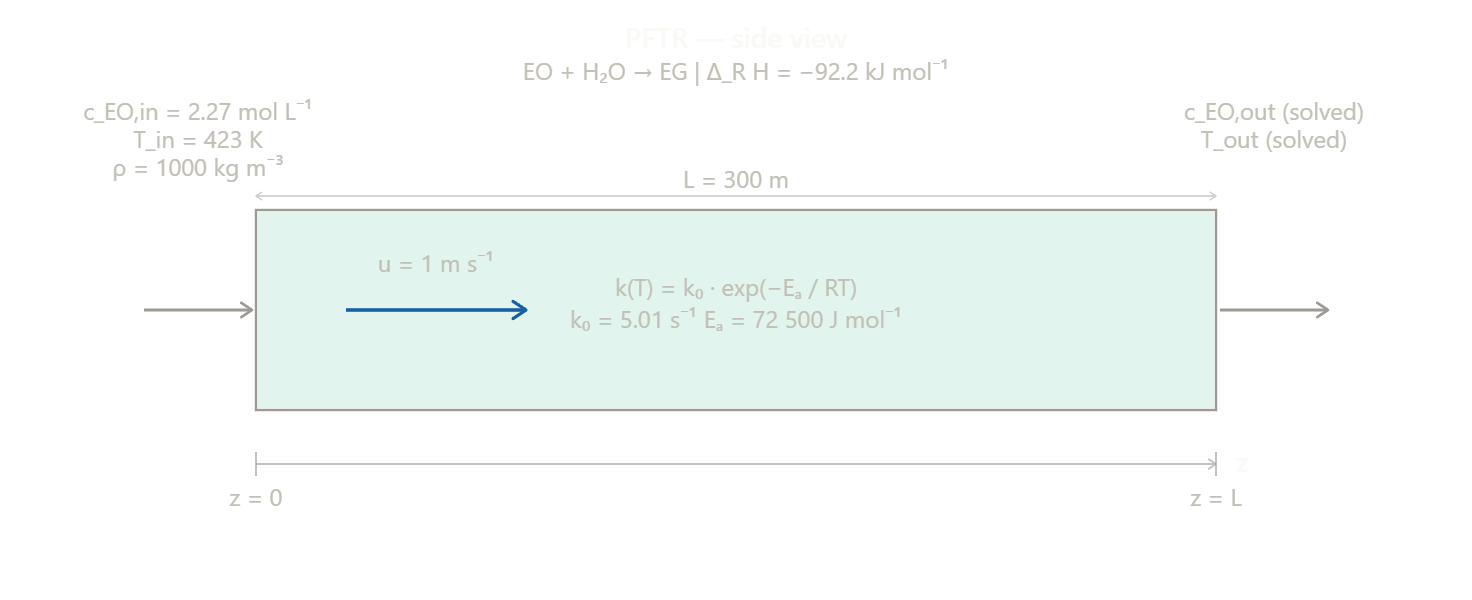

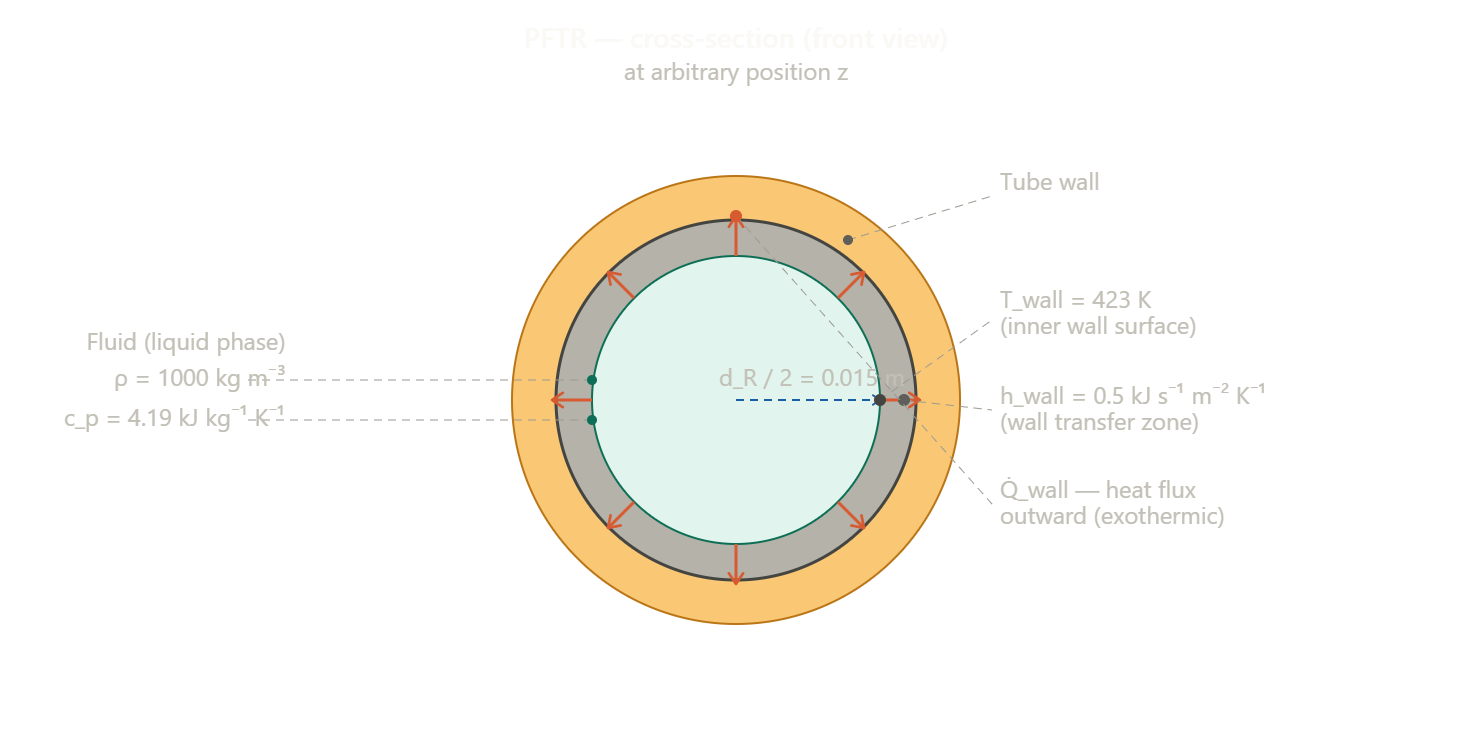

> Note: both .svg graphics were made with AI under human guidance.